In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt

plt.style.use("ggplot")

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/student-performance-dataset/ultimate_student_productivity_dataset_5000.csv


# DATA PREPARATION #

In [2]:
## import the dataframe

df = pd.read_csv("/kaggle/input/student-performance-dataset/ultimate_student_productivity_dataset_5000.csv")
df.head(3)

,student_id,age,gender,academic_level,study_hours,self_study_hours,online_classes_hours,social_media_hours,gaming_hours,sleep_hours,...,exercise_minutes,caffeine_intake_mg,part_time_job,upcoming_deadline,internet_quality,mental_health_score,focus_index,burnout_level,productivity_score,exam_score
0,1,18,Other,High School,7.64,1.56,2.20,3.05,2.19,6.52,...,81,38,1,0,Good,10,43.05,31.77,73.65,50.16
1,2,18,Other,High School,2.21,2.22,2.10,1.65,2.55,5.97,...,111,339,0,0,Good,3,15.92,37.00,13.70,1.00
2,3,22,Male,High School,3.45,0.00,0.29,1.34,2.08,8.39,...,68,266,0,1,Good,8,27.39,34.37,45.15,18.30


In [3]:
## filtering for only high school students

df = df[df["academic_level"] == "High School"]
df["academic_level"].value_counts()


academic_level
High School    1672
Name: count, dtype: int64

In [4]:
## Cutting out some of the columns

columns = ["student_id","age","gender","study_hours","self_study_hours","online_classes_hours","social_media_hours","gaming_hours","sleep_hours","screen_time_hours","exercise_minutes","exam_score"]

df = df[columns]
df.head(3)

,student_id,age,gender,study_hours,self_study_hours,online_classes_hours,social_media_hours,gaming_hours,sleep_hours,screen_time_hours,exercise_minutes,exam_score
0,1,18,Other,7.64,1.56,2.20,3.05,2.19,6.52,6.47,81,50.16
1,2,18,Other,2.21,2.22,2.10,1.65,2.55,5.97,6.05,111,1.00
2,3,22,Male,3.45,0.00,0.29,1.34,2.08,8.39,7.62,68,18.30


In [5]:
## scanning the columns
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1672 entries, 0 to 4996
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   student_id            1672 non-null   int64  
 1   age                   1672 non-null   int64  
 2   gender                1672 non-null   object 
 3   study_hours           1672 non-null   float64
 4   self_study_hours      1672 non-null   float64
 5   online_classes_hours  1672 non-null   float64
 6   social_media_hours    1672 non-null   float64
 7   gaming_hours          1672 non-null   float64
 8   sleep_hours           1672 non-null   float64
 9   screen_time_hours     1672 non-null   float64
 10  exercise_minutes      1672 non-null   int64  
 11  exam_score            1672 non-null   float64
dtypes: float64(8), int64(3), object(1)
memory usage: 169.8+ KB


In [6]:
## summarizing the columns

df.describe()

,student_id,age,study_hours,self_study_hours,online_classes_hours,social_media_hours,gaming_hours,sleep_hours,screen_time_hours,exercise_minutes,exam_score
count,1672.000000,1672.000000,1672.000000,1672.000000,1672.000000,1672.000000,1672.000000,1672.000000,1672.000000,1672.000000,1672.000000
mean,2485.421053,20.473086,4.536531,2.480754,2.032117,3.024492,1.559617,7.059958,7.071657,74.077153,18.809970
std,1428.525902,2.881127,1.870466,1.154794,0.989773,1.435046,1.119233,1.145240,2.498328,42.603618,12.288051
min,1.000000,16.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,1.000000,0.000000,1.000000
25%,1273.750000,18.000000,3.160000,1.677500,1.320000,2.040000,0.650000,6.260000,5.340000,37.000000,9.820000
50%,2473.000000,20.000000,4.500000,2.470000,2.040000,3.000000,1.500000,7.060000,7.080000,74.000000,17.880000
75%,3697.000000,23.000000,5.790000,3.280000,2.730000,4.040000,2.322500,7.840000,8.772500,111.000000,27.365000
max,4997.000000,25.000000,11.840000,6.230000,5.150000,7.650000,5.640000,10.000000,15.300000,149.000000,62.820000


# DATA ANAYSIS #

## Demographic Overview ##

### Overview of respondents per gender identity

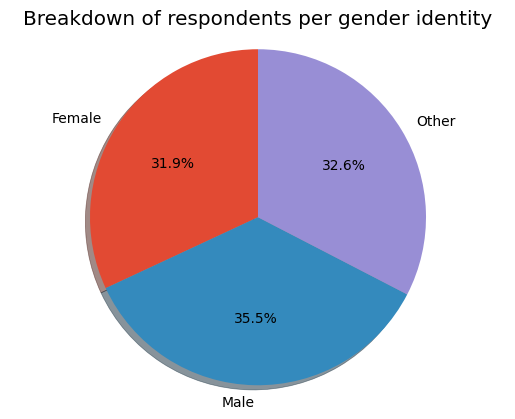

In [7]:
## Counting how many are males and femalse and others

viz_df = df.groupby("gender")["student_id"].count()
viz_df = viz_df.reset_index()
viz_df["percent"] = round(( viz_df["student_id"] / len(df) ) * 100, 2)


## charting the axes

viz_df_x = viz_df["gender"]
viz_df_y = viz_df["student_id"]
viz_df_size = viz_df["percent"]

## plotting the pie chart

plt.pie(viz_df_size, labels=viz_df_x, startangle=90, shadow=True, autopct='%1.1f%%')
plt.axis("equal")

## annotating the chart

plt.title("Breakdown of respondents per gender identity")
plt.show()


### Identifying any difference in exam scores among gender identities ###

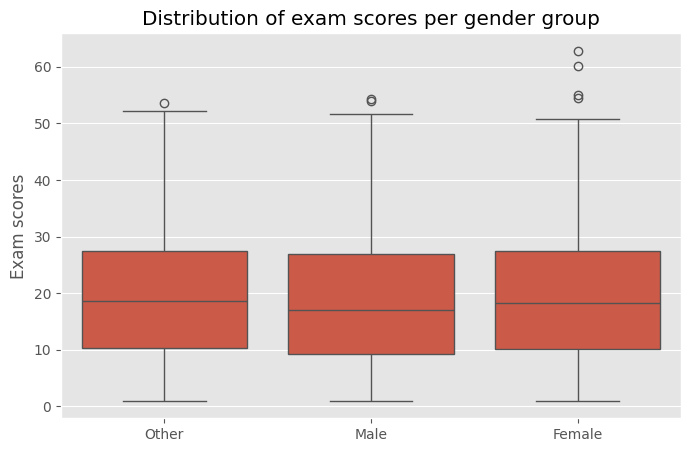

In [8]:
## Creating a boxplot for the dat

viz_df_x = df["gender"]
viz_df_y = df["exam_score"]
viz_df = df[["gender","exam_score"]]

## charting the boxplot

plt.figure(figsize=(8,5))
sns.boxplot(x=viz_df_x, y=viz_df_y)

## annotating the chart

plt.title("Distribution of exam scores per gender group")
plt.ylabel("Exam scores")
plt.xlabel("")
plt.show()

### ANOVA of exam scores per gender groups ###

In [9]:
## importing the correct data

from scipy import stats

## plotting the groups

viz_df_male = df[df["gender"] == "Male"]["exam_score"]
viz_df_female = df[df["gender"] == "Female"]["exam_score"]
viz_df_other = df[df["gender"] == "Other"]["exam_score"]

## performing the anova

f_stat, p_val = stats.f_oneway(viz_df_male, viz_df_female, viz_df_other)
print(f'f Statistic: {f_stat}')
print(f'p-value: {p_val}')
print("There is no statistically significant difference between gender groups in terms of exam scores.")

f Statistic: 0.9331913256388698
p-value: 0.3935016818089737
There is no statistically significant difference between gender groups in terms of exam scores.


### Overview of respondents per age

MEDIAN AGE: 20.5


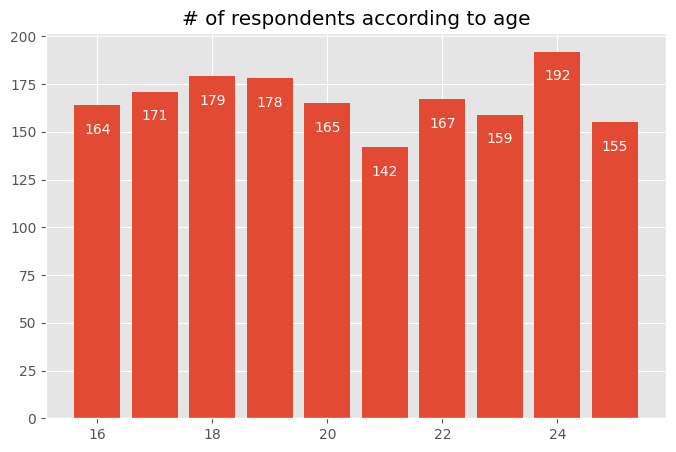

In [10]:
## create a bbar graph for the age groups

viz_df = df.groupby("age")["student_id"].count()
viz_df = viz_df.reset_index()
viz_df = viz_df.sort_values(by="age")

## charting the axes

viz_df_x = viz_df["age"]
viz_df_y = viz_df["student_id"]

## plotting the chart

plt.figure(figsize=(8,5))
plt.bar(viz_df_x, viz_df_y)

## annotating the chart

plt.title("# of respondents according to age")
for x, y in zip(viz_df_x, viz_df_y):
    plt.text(x, y - 15, y, ha="center", color="white")


print(f'MEDIAN AGE: {viz_df["age"].median()}')


plt.show()

### Identifying if age plays a role in exam scores ###

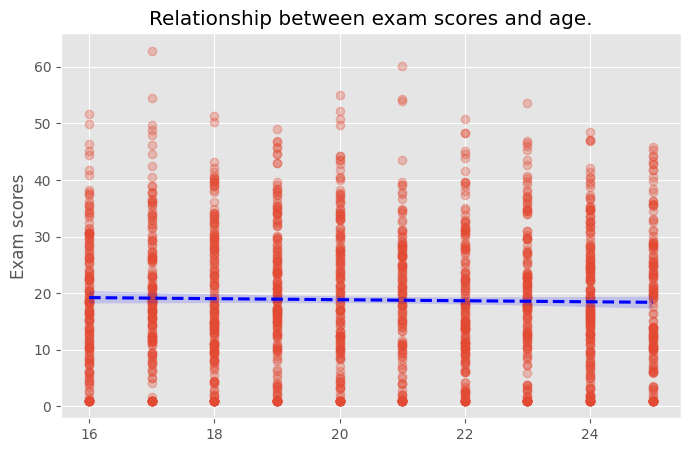

In [11]:
## Plotting a regplot

viz_df = df[["age","exam_score"]]

## plotting the chart

plt.figure(figsize=(8,5))
sns.regplot(data=viz_df,
            x="age",
            y="exam_score",
           line_kws={
               "color":"blue",
               "linestyle":"--"
           },
           scatter_kws={
               "alpha":0.3
           })

## annotating the chart

plt.title("Relationship between exam scores and age.")
plt.xlabel("")
plt.ylabel("Exam scores")

plt.show()

In [12]:
## Finding the pearson coefficient between age and exam score

from scipy import stats

viz_df_age = df["age"]
viz_df_exam = df["exam_score"]

## performing the scores

p_coef, p_val = stats.pearsonr(viz_df_age, viz_df_exam)

print(f'Pearson coefficient: {p_coef}')
print(f'p-value: {p_val}')
print("Extremely weak relationship between age and exam scores")

Pearson coefficient: -0.02156938805525596
p-value: 0.37809199747629085
Extremely weak relationship between age and exam scores


In [13]:
## Using linear regression between age and exam scores

from scipy import stats

viz_df_age = df["age"]
viz_df_exam = df["exam_score"]

## performing the analysis

results = stats.linregress(viz_df_age, viz_df_exam)

results
print(f'R value: -0.0215')
print(f'p-value: 0.3780')

R value: -0.0215
p-value: 0.3780


## Exam Scores Overview ##

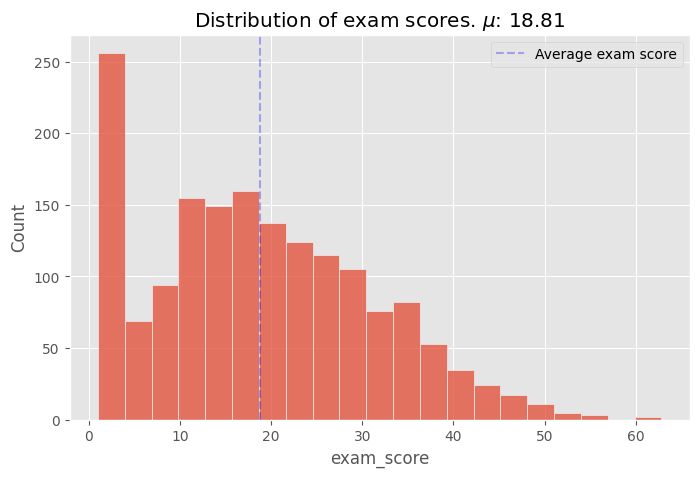

In [14]:
## plotting the histogram for the distribution of scores

viz_df = df["exam_score"]
##viz_df = viz_df.reset_index()

## charting the plot

plt.figure(figsize=(8,5))
sns.histplot(data=viz_df)

## Annotating the chart

avg_exam_score = round(df["exam_score"].mean(), 2)

plt.title(f"Distribution of exam scores. $\\mu$: {avg_exam_score}")
plt.axvline(
    avg_exam_score, linestyle="--",
    color="blue",
    alpha=0.3,
    label="Average exam score"
)
plt.legend()

plt.show()

## STUDY HABITS ANALYSIS ##

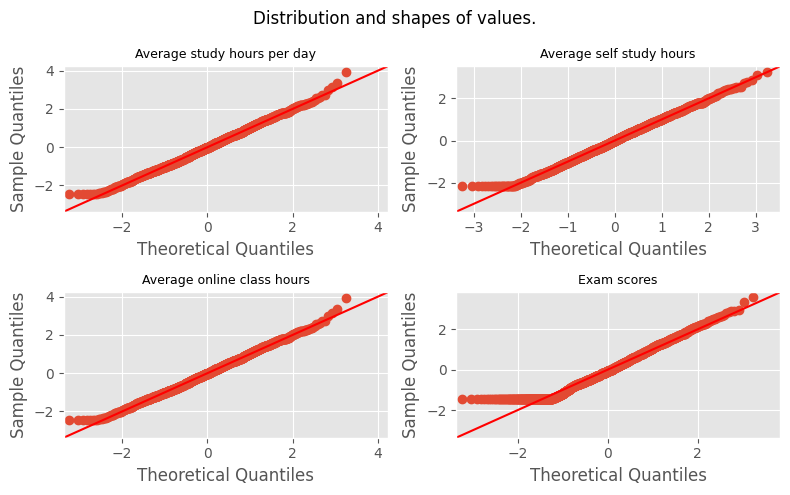

In [15]:
## Finding an overview of the exam scores

viz_df = df[["study_hours","self_study_hours","online_classes_hours", "exam_score"]]


## plotting the qqplot

import statsmodels.api as sm
fig, axes = plt.subplots(2,2, figsize=(8,5))

sm.qqplot(viz_df["study_hours"], line="45", fit=True, ax=axes[0,0])
axes[0,0].set_title("Average study hours per day", size=9)

sm.qqplot(viz_df["self_study_hours"], line="45", fit=True, ax=axes[0,1])
axes[0,1].set_title("Average self study hours", size=9)

sm.qqplot(viz_df["study_hours"], line="45", fit=True, ax=axes[1,0])
axes[1,0].set_title("Average online class hours", size=9)

sm.qqplot(viz_df["exam_score"], line="45", fit=True, ax=axes[1,1])
axes[1,1].set_title("Exam scores", size=9)

fig.suptitle("Distribution and shapes of values.")

plt.tight_layout()
plt.show()

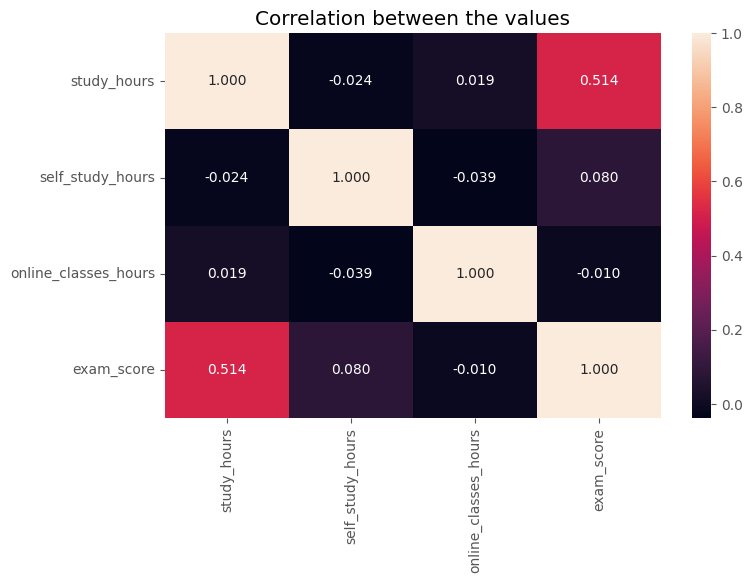

In [16]:
## Finding the correlation of study habits and exam scores

corr_df = df[["study_hours","self_study_hours","online_classes_hours", "exam_score"]]
corr_matrix = corr_df.corr()

## Plotting the charts

plt.figure(figsize=(8,5))
sns.heatmap(corr_matrix, annot=True, fmt=".3f")

## annotate the chart

plt.title("Correlation between the values")
plt.show()

### Linear Regression between study hours and exam scores ###

In [17]:
## doing linear regression

from scipy import stats

viz_df_x = df["study_hours"]
viz_df_y = df["exam_score"]

## perform the regression

results = stats.linregress(viz_df_x, viz_df_y)

print("slope: 3.3781")
print("intercept: 3.4848")
print("r Coefficient: 0.5142")
print("p-value: <0.001")

slope: 3.3781
intercept: 3.4848
r Coefficient: 0.5142
p-value: <0.001


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1672 entries, 0 to 4996
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   student_id            1672 non-null   int64  
 1   age                   1672 non-null   int64  
 2   gender                1672 non-null   object 
 3   study_hours           1672 non-null   float64
 4   self_study_hours      1672 non-null   float64
 5   online_classes_hours  1672 non-null   float64
 6   social_media_hours    1672 non-null   float64
 7   gaming_hours          1672 non-null   float64
 8   sleep_hours           1672 non-null   float64
 9   screen_time_hours     1672 non-null   float64
 10  exercise_minutes      1672 non-null   int64  
 11  exam_score            1672 non-null   float64
dtypes: float64(8), int64(3), object(1)
memory usage: 169.8+ KB
